# How Connected Is the World?

Tracking the internet adoption curve for a handful of countries, from the dial-up era to (nearly) universal access. Data comes from **Our World in Data**'s share of the population using the internet.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_URL = "https://ourworldindata.org/grapher/share-of-individuals-using-the-internet.csv"
VALUE_COL = "Share of the population using the Internet"
HEADERS = {"User-Agent": "Mozilla/5.0"}
SPOTLIGHT_COUNTRIES = ["Poland", "United States", "South Korea", "Nigeria", "India", "Iceland"]

df = pd.read_csv(DATA_URL, storage_options=HEADERS)
countries = df[df["Code"].notna() & ~df["Code"].str.startswith(("OWID", "WB_"))]
countries.tail()

,Entity,Code,Year,Share of the population using the Internet
6471,Zimbabwe,ZWE,2020,29.298565
6472,Zimbabwe,ZWE,2021,32.592400
6473,Zimbabwe,ZWE,2022,36.256500
6474,Zimbabwe,ZWE,2023,38.674800
6475,Zimbabwe,ZWE,2024,41.642800


## Adoption curves

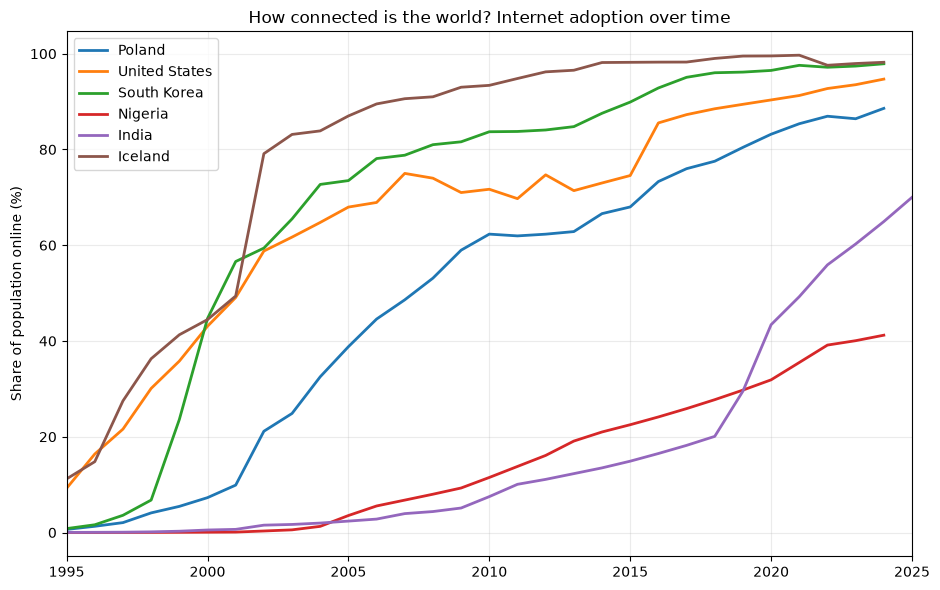

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 6))
for country in SPOTLIGHT_COUNTRIES:
    series = countries[countries["Entity"] == country].sort_values("Year")
    ax.plot(series["Year"], series[VALUE_COL], label=country, linewidth=2)

ax.set_title("How connected is the world? Internet adoption over time")
ax.set_ylabel("Share of population online (%)")
ax.set_xlim(1995, countries["Year"].max())
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Most and least connected countries today

In [3]:
# Some years only have a handful of early-reporting countries; use the
# most recent year with broad coverage for a fair comparison.
latest_year = countries.groupby("Year").size().loc[lambda s: s > 150].index.max()
latest = countries[countries["Year"] == latest_year]

print(f"Most connected in {latest_year}:")
for _, row in latest.sort_values(VALUE_COL, ascending=False).head(5).iterrows():
    print(f"  {row['Entity']}: {row[VALUE_COL]:.1f}%")

print(f"\nLeast connected in {latest_year}:")
for _, row in latest.sort_values(VALUE_COL).head(5).iterrows():
    print(f"  {row['Entity']}: {row[VALUE_COL]:.1f}%")

Most connected in 2024:
  Bahrain: 100.0%
  United Arab Emirates: 100.0%
  Saudi Arabia: 100.0%
  Denmark: 99.8%
  Kuwait: 99.7%

Least connected in 2024:
  Burundi: 8.6%
  Uganda: 8.9%
  Chad: 12.6%
  Central African Republic: 13.8%
  Niger: 15.6%
